# Phase 1: Data Pipeline
### PNW Regional Economic Health Dashboard

**Author:** Thomas Lee  
**Date:** March 2026  
**Project:** [GitHub Repository](https://github.com/your-repo-link)

---

## Overview

This notebook walks through the Phase 1 data pipeline for the PNW Regional Economic Health Dashboard. The goal of Phase 1 is straightforward: **get clean, reliable economic data flowing from public APIs into a format the dashboard can consume**.

By the end of this notebook, it will be established:
- What data sources we use and why
- How the FRED API works and how we interact with it
- How raw API responses are normalised into a consistent schema
- How the CSV caching layer works and why it matters
- What the final processed dataset looks like

The production pipeline is implemented in `src/config.py` and `src/data_fetcher.py`. This notebook explains the thinking behind those modules and demonstrates their behaviour interactively.

---

## Table of Contents
1. [Data Sources](#1-data-sources)
2. [Environment Setup](#2-environment-setup)
3. [Connecting to the FRED API](#3-connecting-to-the-fred-api)
4. [Fetching a Single Series](#4-fetching-a-single-series)
5. [Normalisation: Enforcing a Schema Contract](#5-normalisation-enforcing-a-schema-contract)
6. [The Caching Layer](#6-the-caching-layer)
7. [Fetching All Series and Merging](#7-fetching-all-series-and-merging)
8. [Inspecting the Final Dataset](#8-inspecting-the-final-dataset)
9. [What's Next — Phase 2](#9-whats-next--phase-2)

---
## 1. Data Sources

All data in Phase 1 comes from **FRED** (Federal Reserve Economic Data), a public API maintained by the St. Louis Federal Reserve. FRED hosts hundreds of thousands of economic time series and provides free API access with a registered key.

We track four indicators chosen to give a broad picture of regional economic health:

| Indicator | FRED Series ID | Frequency | Why it matters |
|-----------|---------------|-----------|----------------|
| Oregon Unemployment Rate | `ORUR` | Monthly | Labour market health — a lagging indicator of economic stress |
| CPI – Western Urban Areas | `CUURA400SA0` | Monthly | Inflation pressure on Pacific Northwest consumers |
| Portland Metro Home Price Index | `ATNHPIUS38900Q` | Quarterly | Housing affordability and regional wealth |
| Federal Funds Rate | `FEDFUNDS` | Monthly | Monetary policy context — drives mortgage rates and borrowing costs |

The BLS (Bureau of Labor Statistics) API is scaffolded in the pipeline for Phase 2 expansion (e.g. Portland nonfarm payrolls), but not active in Phase 1.

**Why these four together?**  
They tell a connected story. The Fed raises rates → mortgage costs rise → home prices cool → consumer spending slows → unemployment rises. Tracking all four lets us see that chain play out in the data.

---
## 2. Environment Setup

API keys are managed via a `.env` file and loaded with `python-dotenv`. This means keys are **never hardcoded** in source files or notebooks — a non-negotiable practice for any project that will be shared or deployed.

The `.env` file lives in the project root and is excluded from git via `.gitignore`. A `.env.example` template is committed so collaborators know what keys are needed.

```
# .env.example
FRED_API_KEY=your_fred_api_key_here
BLS_API_KEY=your_bls_api_key_here
```

FRED API keys are free at: https://fred.stlouisfed.org/docs/api/api_key.html

In [4]:
import os
import sys
from pathlib import Path

import pandas as pd
from dotenv import load_dotenv
from fredapi import Fred

# Ensure the project root is on the path so we can import src modules
PROJECT_ROOT = Path().resolve().parent  # notebooks/ → project root

# Add project root to sys.path so src/ is importable
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Load .env from project root
load_dotenv(PROJECT_ROOT / ".env")

FRED_API_KEY = os.getenv("FRED_API_KEY")
assert FRED_API_KEY, "FRED_API_KEY not found — check your .env file"

print(f"✓ FRED API key loaded ({FRED_API_KEY[:4]}...{FRED_API_KEY[-4:]})")
print(f"✓ Python {sys.version.split()[0]}")
print(f"✓ pandas {pd.__version__}")

✓ FRED API key loaded (e0b6...ded2)
✓ Python 3.12.2
✓ pandas 2.2.2


---
## 3. Connecting to the FRED API

We use the `fredapi` Python wrapper, which handles authentication and HTTP under the hood. In the production module, the `Fred` client is instantiated once at module level — creating it repeatedly would be wasteful.

The series IDs and their metadata are centralised in `src/config.py` rather than scattered across the codebase. This means adding a new indicator to the dashboard requires editing exactly one file.

In [6]:
from src.config import FRED_SERIES

# Instantiate the FRED client
fred = Fred(api_key=FRED_API_KEY)

# Inspect our series configuration
print("Configured FRED series:\n")
for key, meta in FRED_SERIES.items():
    print(f"  {key:25s} → {meta['series_id']:20s} ({meta['frequency']})")

Configured FRED series:

  unemployment_rate         → ORUR                 (Monthly)
  cpi_west                  → CUURA400SA0          (Monthly)
  home_price_index          → ATNHPIUS38900Q       (Quarterly)
  fed_funds_rate            → FEDFUNDS             (Monthly)


---
## 4. Fetching a Single Series

Let's walk through what happens when we fetch one series — Oregon Unemployment Rate (`ORUR`) — before looking at the full pipeline.

The `fredapi` library returns a `pandas.Series` with a `DatetimeIndex`. This is already pretty clean, but it needs normalisation before it's usable in a multi-series dashboard.

In [8]:
# Raw pull from the FRED API
raw = fred.get_series("ORUR", observation_start="2000-01-01")

print(f"Type    : {type(raw)}")
print(f"Shape   : {raw.shape}")
print(f"dtype   : {raw.dtype}")
print(f"Index   : {type(raw.index).__name__}")
print(f"Tz info : {raw.index.tz}")
print(f"\nFirst 5 observations:")
print(raw.head())
print(f"\nLast 5 observations:")
print(raw.tail())

Type    : <class 'pandas.core.series.Series'>
Shape   : (312,)
dtype   : float64
Index   : DatetimeIndex
Tz info : None

First 5 observations:
2000-01-01    5.0
2000-02-01    5.0
2000-03-01    5.1
2000-04-01    5.1
2000-05-01    5.2
dtype: float64

Last 5 observations:
2025-08-01    5.0
2025-09-01    5.2
2025-10-01    NaN
2025-11-01    5.2
2025-12-01    5.2
dtype: float64


The raw series is usable, but notice a few things we'll want to standardise across all series:

- The Series has no name — we need to name it after our internal key
- The index has no explicit name — we want it consistently named `"date"`
- There may be NaN values (FRED uses NaN for missing observations)
- There may be timezone info on the index (inconsistent across series)

This is what the normalisation step handles.

---
## 5. Normalisation: Enforcing a Schema Contract

A **schema contract** is a promise about what a DataFrame will always look like, regardless of which series it contains. Without one, every downstream consumer (the dashboard, the forecasting layer, the tests) has to defensively handle inconsistencies.

Our contract for every DataFrame returned by the pipeline:

| Property | Value |
|----------|-------|
| Index type | `DatetimeIndex` |
| Index name | `"date"` |
| Timezone | UTC-naive (no tz info) |
| Column name | Internal config key (e.g. `"unemployment_rate"`) |
| Value dtype | `float64` |
| Null rows | None (dropped) |
| Duplicate index | None (deduplicated) |
| Sort order | Ascending by date |

The `_normalise_fred_series()` function in `data_fetcher.py` enforces all of these properties in a single pass.

In [11]:
def normalise_fred_series(raw: pd.Series, key: str) -> pd.DataFrame:
    """Inline version of src.data_fetcher._normalise_fred_series for demonstration."""
    df = raw.to_frame(name=key)                          # Series → DataFrame, named column
    df.index = pd.to_datetime(df.index).tz_localize(None) # strip any timezone info
    df.index.name = "date"                               # enforce index name
    df = df.dropna()                                     # remove missing observations
    df[key] = df[key].astype("float64")                  # enforce dtype
    df = df[~df.index.duplicated(keep="last")]           # deduplicate (rare but safe)
    df.sort_index(inplace=True)                          # ensure ascending order
    return df


df_unemployment = normalise_fred_series(raw, "unemployment_rate")

print("After normalisation:")
print(f"  Shape      : {df_unemployment.shape}")
print(f"  Index name : {df_unemployment.index.name}")
print(f"  dtype      : {df_unemployment['unemployment_rate'].dtype}")
print(f"  Nulls      : {df_unemployment.isnull().sum().sum()}")
print(f"  Sorted     : {df_unemployment.index.is_monotonic_increasing}")
print()
df_unemployment.head()

After normalisation:
  Shape      : (311, 1)
  Index name : date
  dtype      : float64
  Nulls      : 0
  Sorted     : True



,unemployment_rate
date,
2000-01-01,5.0
2000-02-01,5.0
2000-03-01,5.1
2000-04-01,5.1
2000-05-01,5.2


---
## 6. The Caching Layer

Making API calls on every pipeline run is slow during development and burns through rate limits. The caching layer solves this by:

1. Saving each normalised series to `data/raw/<key>.csv` after the first fetch
2. Loading from cache on subsequent runs when `use_cache=True`
3. Falling back to the API if no cache file exists

The cache directory is excluded from git via `.gitignore` — raw data is always regenerable from the pipeline, so there's no reason to commit it.

In production, `run_pipeline.py` exposes a `--no-cache` flag to force a fresh API pull (useful for scheduled runs or when you need the latest data).

In [13]:
import time
from src.data_fetcher import fetch_fred_series

# First call — hits the API
t0 = time.time()
df1 = fetch_fred_series("unemployment_rate", use_cache=False)
api_time = time.time() - t0

# Second call — reads from cache
t0 = time.time()
df2 = fetch_fred_series("unemployment_rate", use_cache=True)
cache_time = time.time() - t0

print(f"API call  : {api_time:.3f}s")
print(f"Cache hit : {cache_time:.3f}s")
print(f"Speedup   : {api_time / cache_time:.0f}x")
print(f"\nDataFrames are identical: {df1.equals(df2)}")

2026-03-18 11:09:16  INFO      src.data_fetcher — Fetching FRED series 'ORUR' (Oregon Unemployment Rate) from 2000-01-01 to today
2026-03-18 11:09:16  INFO      src.data_fetcher — Loading 'unemployment_rate' from cache (data/raw/unemployment_rate.csv)


API call  : 0.215s
Cache hit : 0.004s
Speedup   : 55x

DataFrames are identical: True


---
## 7. Fetching All Series and Merging

`fetch_all_fred()` loops over every key in `config.FRED_SERIES`, fetches each one, and merges them into a single DataFrame using `pd.concat(..., join="outer")`.

The **outer join** is important here. Our series have different frequencies:
- Monthly series (unemployment, CPI, fed funds) → one row per month
- Quarterly series (home price index) → one row per quarter

An outer join preserves every timestamp from every series. The quarterly column will have NaN values for the two months between each quarterly observation — this is **expected and intentional**. The dashboard layer will handle these with forward-fill before charting.

In [15]:
from src.data_fetcher import fetch_all_fred

df_all = fetch_all_fred(use_cache=True)

print("Merged DataFrame:")
print(f"  Shape      : {df_all.shape}")
print(f"  Date range : {df_all.index.min().date()} → {df_all.index.max().date()}")
print(f"  Columns    : {list(df_all.columns)}")
print()
print("Missing value counts (by design for quarterly series):")
print(df_all.isnull().sum())

2026-03-18 11:09:16  INFO      src.data_fetcher — Loading 'unemployment_rate' from cache (data/raw/unemployment_rate.csv)
2026-03-18 11:09:16  INFO      src.data_fetcher — Loading 'cpi_west' from cache (data/raw/cpi_west.csv)
2026-03-18 11:09:16  INFO      src.data_fetcher — Loading 'home_price_index' from cache (data/raw/home_price_index.csv)
2026-03-18 11:09:16  INFO      src.data_fetcher — Loading 'fed_funds_rate' from cache (data/raw/fed_funds_rate.csv)
2026-03-18 11:09:16  INFO      src.data_fetcher — Merged 4 FRED series into DataFrame with shape (314, 4)


Merged DataFrame:
  Shape      : (314, 4)
  Date range : 2000-01-01 → 2026-02-01
  Columns    : ['unemployment_rate', 'cpi_west', 'home_price_index', 'fed_funds_rate']

Missing value counts (by design for quarterly series):
unemployment_rate      3
cpi_west               1
home_price_index     210
fed_funds_rate         0
dtype: int64


In [16]:
# The quarterly home price index is sparse by design — NaNs between quarters
# This is what a forward-fill will fix in Phase 2
print("Home price index — showing quarterly pattern:")
df_all[["home_price_index"]].dropna().tail(8)

Home price index — showing quarterly pattern:


,home_price_index
date,
2024-01-01,432.44
2024-04-01,441.50
2024-07-01,441.31
2024-10-01,441.33
2025-01-01,444.17
2025-04-01,451.15
2025-07-01,449.38
2025-10-01,449.30


---
## 8. Inspecting the Final Dataset

Let's do a final inspection of the processed dataset — the same file saved to `data/processed/all_indicators.csv` by the production pipeline.

In [18]:
print("=" * 55)
print("DATASET SUMMARY")
print("=" * 55)
print(df_all.describe().round(2))

DATASET SUMMARY
       unemployment_rate  cpi_west  home_price_index  fed_funds_rate
count             311.00    313.00            104.00          314.00
mean                6.26    247.60            258.67            2.02
std                 2.14     49.91             98.24            2.03
min                 3.40    172.30            132.00            0.05
25%                 4.30    209.70            185.49            0.15
50%                 5.60    239.34            227.84            1.26
75%                 7.70    279.73            318.86            3.96
max                13.70    358.74            451.15            6.54


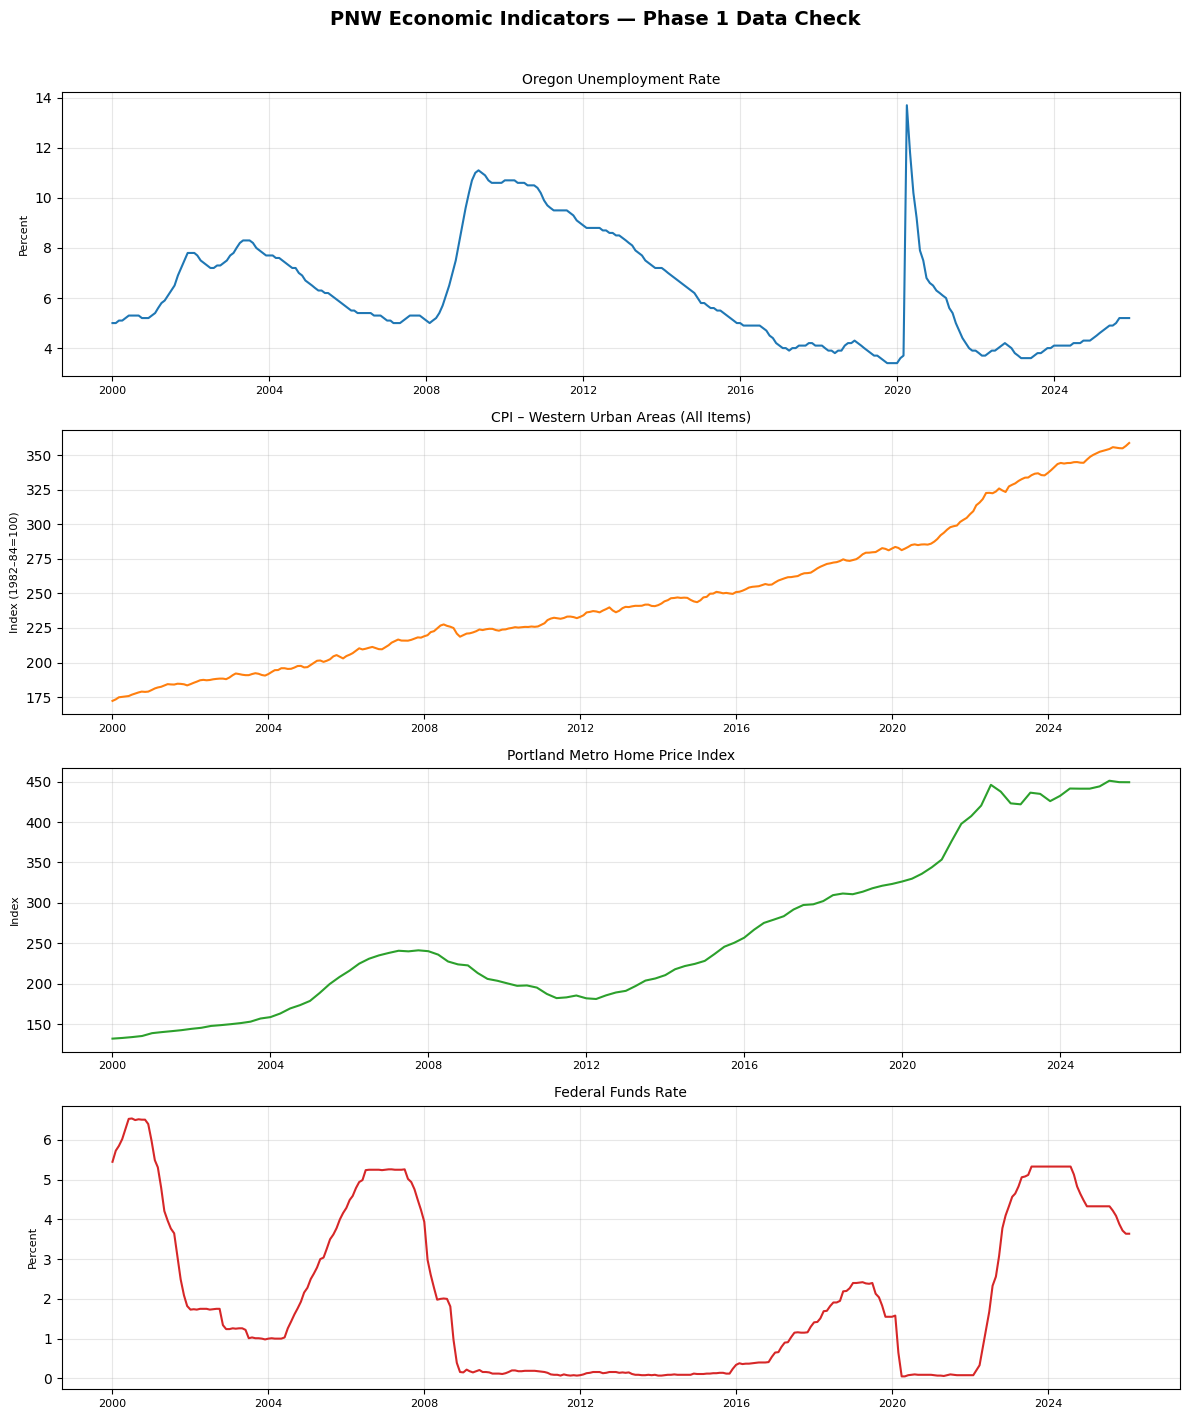


Chart saved to phase1_data_check.png


In [19]:
# Quick visual check — one line chart per series
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.config import FRED_SERIES

fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=False)
fig.suptitle("PNW Economic Indicators — Phase 1 Data Check", fontsize=14, fontweight="bold", y=1.01)

plot_configs = [
    ("unemployment_rate", "tab:blue"),
    ("cpi_west",          "tab:orange"),
    ("home_price_index",  "tab:green"),
    ("fed_funds_rate",    "tab:red"),
]

for ax, (key, color) in zip(axes, plot_configs):
    series = df_all[key].dropna()
    ax.plot(series.index, series.values, color=color, linewidth=1.5)
    ax.set_title(FRED_SERIES[key]["label"], fontsize=10)
    ax.set_ylabel(FRED_SERIES[key]["units"], fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(4))
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", labelsize=8)

plt.tight_layout()
plt.savefig("phase1_data_check.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nChart saved to phase1_data_check.png")

In [20]:
# Final preview — last 8 rows of the processed dataset
print("Last 8 rows of all_indicators.csv:")
df_all.tail(8).round(3)

Last 8 rows of all_indicators.csv:


,unemployment_rate,cpi_west,home_price_index,fed_funds_rate
date,,,,
2025-07-01,4.9,353.713,449.38,4.33
2025-08-01,5.0,354.431,NaN,4.33
2025-09-01,5.2,355.713,NaN,4.22
2025-10-01,NaN,NaN,449.30,4.09
2025-11-01,5.2,354.998,NaN,3.88
2025-12-01,5.2,354.879,NaN,3.72
2026-01-01,NaN,356.583,NaN,3.64
2026-02-01,NaN,358.741,NaN,3.64


**Reading the tail of the dataset:**

- `home_price_index` shows NaN for most recent months — the quarterly series has a publication lag and only updates every 3 months. This is expected.
- `unemployment_rate` and `cpi_west` may show NaN for the most recent 1–2 months — government statistics are typically published 3–6 weeks after the reference period.
- `fed_funds_rate` is always current — the Fed publishes this promptly.

None of these NaNs represent data quality issues. They're publication lags inherent to the source data.

---
## 9. What's Next — Phase 2

Phase 1 delivers a clean, cached, well-tested data pipeline. The processed dataset at `data/processed/all_indicators.csv` is the single input for everything that follows.

**Phase 2: Core Streamlit Dashboard** will:
- Load this dataset via `src.data_fetcher.load_processed()`
- Forward-fill the quarterly home price index for continuous charting
- Build interactive multi-panel charts with a date range selector
- Deploy to Streamlit Community Cloud

**Phase 3: Data Science Layer** will add:
- Prophet forecasting for each indicator
- Anomaly detection to flag unusual observations
- A "So What?" narrative section translating the data into plain-language insight

---

### Key files from this phase

| File | Purpose |
|------|---------|
| `src/config.py` | Series IDs, labels, shared settings |
| `src/data_fetcher.py` | FRED + BLS ingestion, normalisation, caching |
| `run_pipeline.py` | CLI entry point — run this to refresh data |
| `tests/test_data_fetcher.py` | 17 unit tests covering normalisation, cache, key validation |
| `data/processed/all_indicators.csv` | Final output — 314 rows × 4 indicators, 2000–present |